In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = 'BybaneData.csv'

data=pd.read_csv(path)

<AxesSubplot: xlabel='Time (s)'>

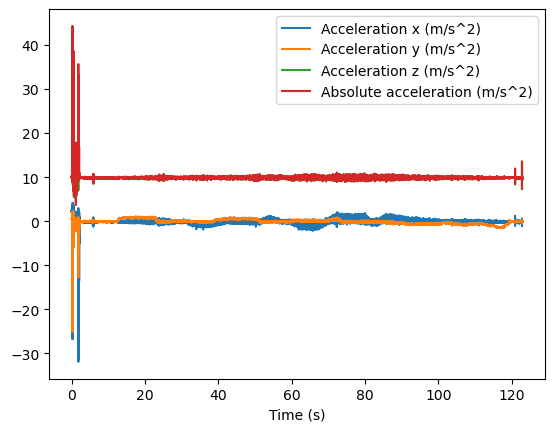

In [2]:
data.plot(x='Time (s)')

In [3]:
data

,Time (s),Acceleration x (m/s^2),Acceleration y (m/s^2),Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.010686,2.229812,0.668495,9.847063,10.118478
1,0.013124,2.155634,0.754636,9.847063,10.108456
2,0.015562,2.165205,0.800399,9.815957,10.083738
3,0.018000,2.256133,0.824327,9.756136,10.047479
4,0.020438,2.349752,0.833899,9.727423,10.041886
...,...,...,...,...,...
51471,122.957733,-0.147458,-0.107079,9.784850,9.786547
51472,122.960114,-0.085244,-0.114257,9.780065,9.781103
51473,122.962496,-0.176172,-0.121436,9.770494,9.772836
51474,122.964877,-0.113958,-0.152542,9.849456,9.851296


<AxesSubplot: xlabel='Time (s)'>

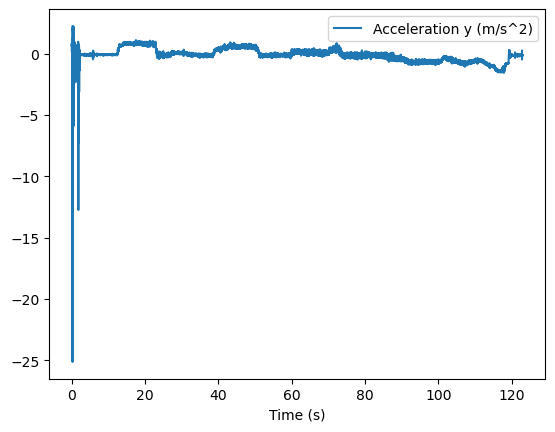

In [4]:
data.plot(x='Time (s)',y='Acceleration y (m/s^2)')


<AxesSubplot: xlabel='Time (s)'>

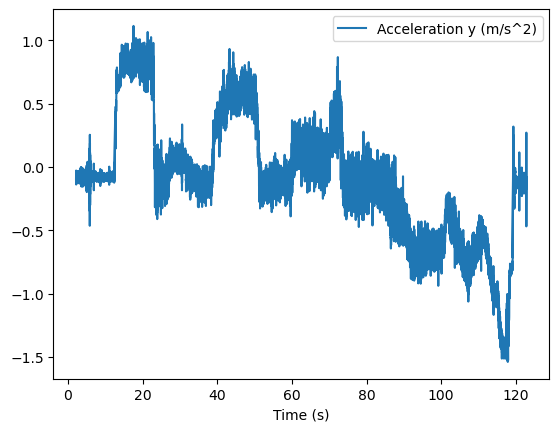

In [5]:
data[890:].plot(x='Time (s)',y='Acceleration y (m/s^2)')

In [6]:
data2 = data[890:]

In [7]:
yaks = np.array(data2['Acceleration y (m/s^2)'])
xaks = np.array(data2['Acceleration x (m/s^2)'])
tid = np.array(data2['Time (s)'])

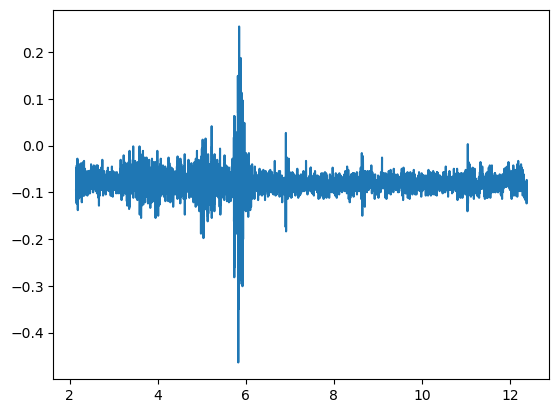

In [8]:
#kalirerer med noen sekunder hvor bybanen står i ro, sjekker med å plott
plt.plot(tid[:4300],yaks[:4300])

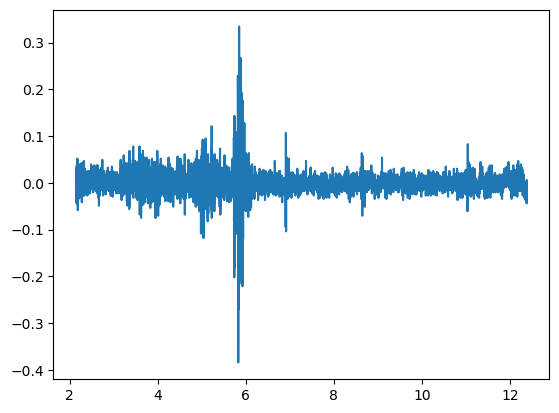

In [9]:
# kalibrerer og skjekker 
yaks = yaks-np.mean(yaks[:4300])
plt.plot(tid[:4300],yaks[:4300])

maxfart i følge mine målinger: 70.7624264118706


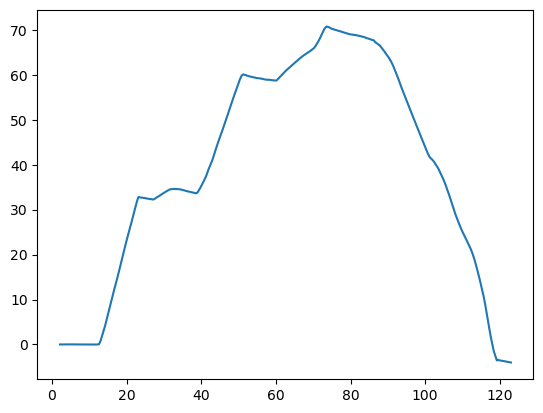

In [10]:
fart=np.cumsum(yaks[:-1]*np.diff(tid))
fart_km_h=fart*3.6
print('maxfart i følge mine målinger:',np.max(fart_km_h))
plt.plot(tid[:-1],fart_km_h);

In [57]:
delta_s = fart*np.diff(tid)
strekning = np.cumsum(delta_s)

1334.2797522470476

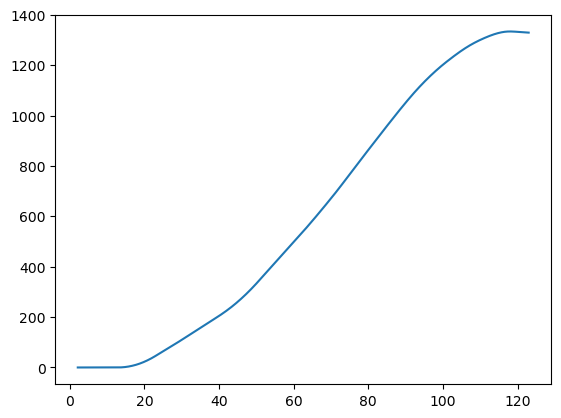

In [44]:
plt.plot(tid[:-1],strekning)
np.max(strekning)

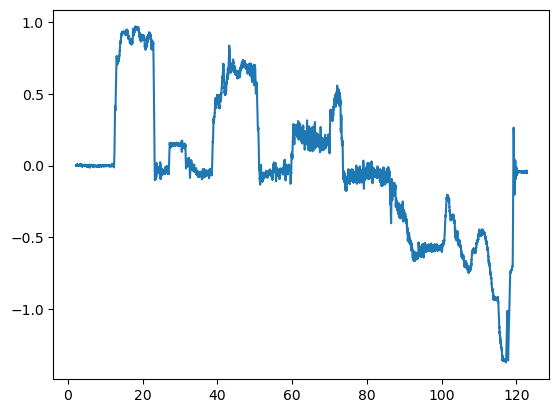

In [13]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

avax = moving_average(yaks,51)
plt.plot(tid[:-50],avax)

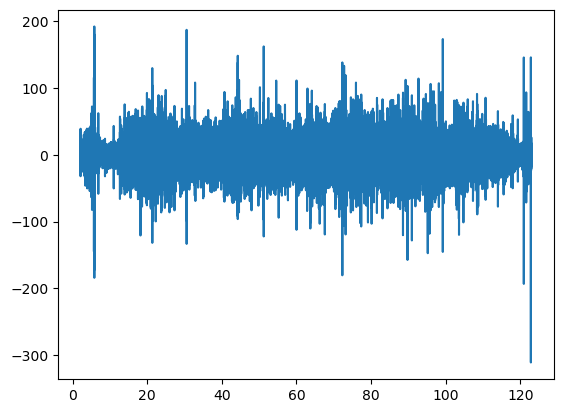

In [14]:
rykk = np.diff(yaks)/np.diff(tid)
plt.plot(tid[:-1],rykk)

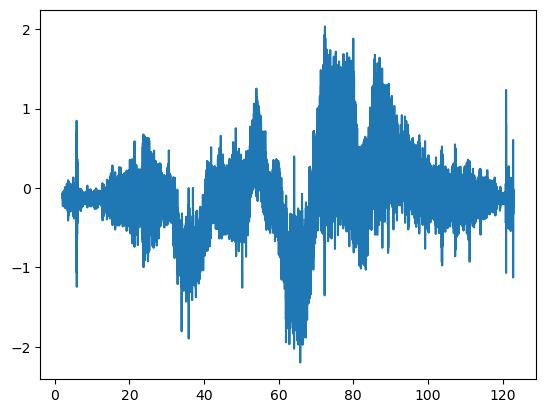

In [15]:
plt.plot(tid,xaks)

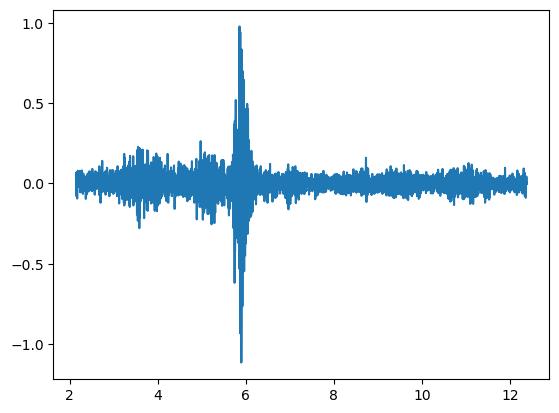

In [16]:
xaks = xaks-np.mean(xaks[:4300])
plt.plot(tid[:4300],xaks[:4300])

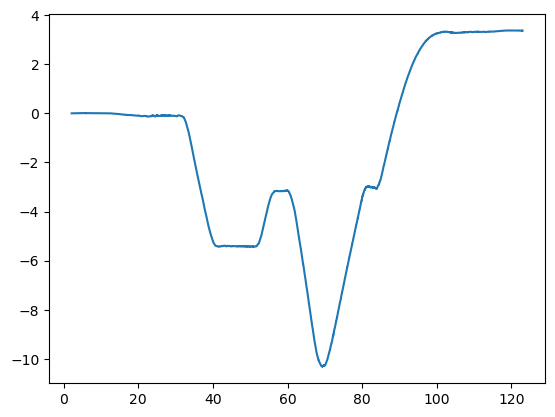

In [17]:
xfart = np.cumsum(xaks[:-1]*np.diff(tid))
plt.plot(tid[:-1],xfart)

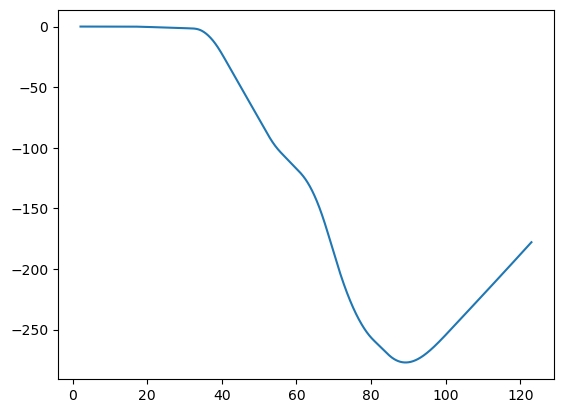

In [18]:
xposisjon = np.cumsum(xfart*np.diff(tid))
plt.plot(tid[:-1],xposisjon)

(-500.0, 900.0)

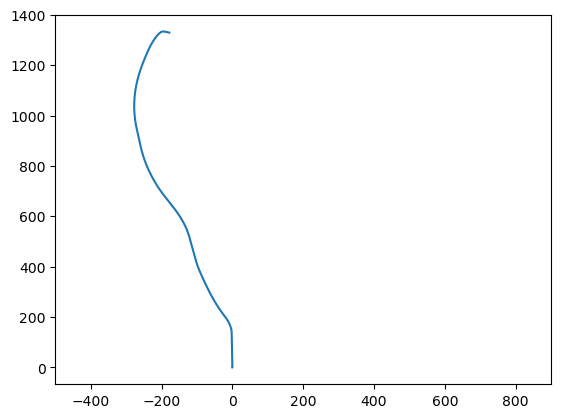

In [45]:
# dette gir ikke helt mening må regne md vinkler?
plt.plot(xposisjon,strekning)
plt.xlim((-500,900))

In [69]:
retningsvektor = np.array([0,1])
normal = np.flip(retningsvektor)*np.array([1,-1])

ax_snitt=(xaks[:-1]+xaks[1:])/2
radius = np.zeros(len(ax_snitt))
thetha = np.zeros(len(ax_snitt))
posisjon = np.zeros((len(ax_snitt),2))
pos_now = np.array([0,0])

for i in range(len(ax_snitt)):
    if ax_snitt[i]==0:
        # radius[i]=np.nan
        pos_now = pos_now + renintgsvektor*delta_s
        posisjon[i] = pos_now 
    else:
        radius[i]=fart[i]**2/ax_snitt[i]
        thetha[i] = delta_s[i]/radius[i]
        sentrum = pos_now + radius[i]*normal
        #x_2=retning(
        #retning = np.array([r
        

In [49]:
sentrum

array([33.53148164,  0.        ])

In [51]:
radius*normal

array([33.53148164,  0.        ])

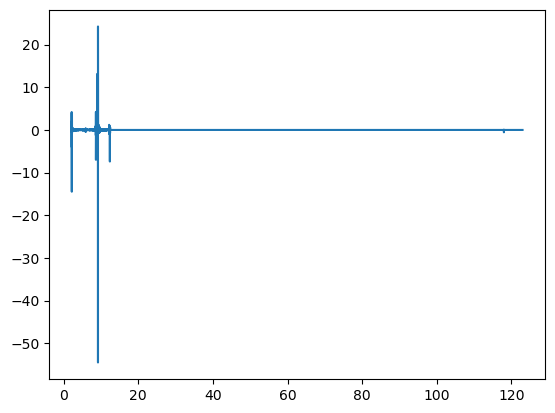

In [70]:
plt.plot(tid[1:],thetha)